<p style="font-size:300%; background-color:#ffe6f0; color:#0044cc; text-align:center; line-height:80px; margin:0; padding:0;">
  <b>Aprendizaje de Máquina</b>
</p>

<p style="font-size:240%; background-color:#ffe6f0; color:#cc0000; text-align:center; line-height:60px; margin:0; padding:0;">
  <b>Técnicas de Inteligencia Artificial</b>
</p>

<p style="font-size:200%; text-align:center; line-height:40px; margin:0;">
  <br><b>Prof. Flavio Prieto</b>
</p>

<p style="font-size:160%; text-align:center; line-height:25px; margin:0;">
  email: <a href="mailto:faprietoo@unal.edu.co">faprietoo@unal.edu.co</a>
</p>

<p style="font-size:180%; text-align:center; line-height:30px; margin:0;">
  <br><b>DEPARTAMENTO DE INGENIERÍA MECÁNICA Y MECATRÓNICA</b>
</p>

<p style="font-size:180%; text-align:center; line-height:30px; margin:0;">
  Facultad de Ingeniería
</p>

<p style="font-size:160%; text-align:center; line-height:30px; margin:0;">
  Universidad Nacional de Colombia – Sede Bogotá
</p>

<div style="text-align:center; margin-top:20px; margin-bottom:10px;">
  <img src="Fig/Escudo_UN.png" alt="Escudo UNAL" width="90" style="border:none;">
</div>

# APRENDIZAJE POR REFUERZO
<div style="border: 2px solid #4CAF50; padding: 10px; border-radius: 8px; background-color: #e8f5e9; text-align: center;">
  <strong style="font-size: 32px;">APRENDIZAJE POR REFUERZO</strong>
</div>

# Entorno para un robot navegando en un grid 2D

Se implementa un entorno de aprendizaje por refuerzo donde un robot debe ir desde una posición inicial $(x0, y0)$ hasta una meta $(x1, y1)$ en un grid 2D, evitando obstáculos.

In [1]:
#import sys
#!{sys.executable} -m pip install gymnasium

In [2]:
# ================================================================
# Librerías
# ================================================================

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import random

import gymnasium as gym
from gymnasium import spaces


In [3]:
#==================================================================
# Define un entorno personalizado de RL
#==================================================================

class GridRobotEnv(gym.Env):
    def __init__(self, grid_size=10, start=(0,0), goal=(9,9), obstacles=[(4,4),(4,5),(5,4),(5,5)]):
        super().__init__()
        self.grid_size = grid_size       # tamaño de la grilla (10x10)
        self.start = start               # posición inicial
        self.goal = goal                 # objetivo
        self.obstacles = obstacles       # celdas prohibidas
        self.state = self.start          # Estado del entorno s=(x,y)
        self.trajectory = [self.start]   # guarda posiciones visitadas
        
        # Posibes acciones: 0=arriba, 1=abajo, 2=izq, 3=der
        self.action_space = spaces.Discrete(4)
        # Estado: posición (x,y)
        self.observation_space = spaces.Box(low=0, high=grid_size-1, shape=(2,), dtype=np.int32)
    
    # def reset(self):                    # Reinicia el entorno
    #     self.state = self.start         # Vuelve al inicio
    #     self.trajectory = [self.start]  # Limpia la trayectoria
    #     return np.array(self.state)

    # def reset(self, start=None):
    #     if start is not None:
    #         self.start = start
    #     self.state = self.start
    #     self.trajectory = [self.state]
    #     return np.array(self.state)

    def reset(self, start=None, goal=None):
        if start is not None:
            self.start = start
        if goal is not None:
            self.goal = goal

        self.state = self.start
        self.trajectory = [self.state]
        return np.array(self.state)

    
    def step(self, action):
        x,y = self.state
        if action==0: y = min(y+1,self.grid_size-1) # Mueve el robot en la grilla respetando límites
        elif action==1: y = max(y-1,0)
        elif action==2: x = max(x-1,0)
        elif action==3: x = min(x+1,self.grid_size-1)

        # Actualiza estado
        self.state = (x,y)
        self.trajectory.append(self.state)  # guardar trayectoria
        
        # Recompensa
        reward = -0.01 # Penaliza cada paso → incentiva caminos cortos
        done = False
        
        if self.state == self.goal: # Caso 1: llega a la meta
            reward = 1.0
            done = True
        elif self.state in self.obstacles: # Caso 2: cae en obstáculo
            reward = -0.5 # en vez de -1 
            #done = True
            done = False  # permitir continuar
            
        return np.array(self.state), reward, done, {}
    
    def render_trajectory(self):
        """Muestra la trayectoria final con flechas numeradas."""
        fig, ax = plt.subplots(figsize=(6,6))
        ax.set_xlim(-0.5, self.grid_size-0.5)
        ax.set_ylim(-0.5, self.grid_size-0.5)
        ax.set_aspect("equal")
        
        # Dibujar grilla
        for i in range(self.grid_size):
            ax.axhline(i-0.5, color="lightgray", linewidth=0.5)
            ax.axvline(i-0.5, color="lightgray", linewidth=0.5)
        
        # Obstáculos
        for (ox, oy) in self.obstacles:
            ax.add_patch(plt.Rectangle((ox-0.5, oy-0.5), 1, 1, color="black"))
        
        # Meta
        gx, gy = self.goal
        ax.add_patch(plt.Rectangle((gx-0.5, gy-0.5), 1, 1, color="green"))
        
        # Inicio
        sx, sy = self.start
        ax.add_patch(plt.Rectangle((sx-0.5, sy-0.5), 1, 1, color="orange"))
        
        # Dibujar trayectoria con flechas numeradas
        for step_idx, ((x0,y0), (x1,y1)) in enumerate(zip(self.trajectory[:-1], self.trajectory[1:]), start=1):
            dx, dy = x1-x0, y1-y0
            ax.arrow(x0, y0, dx*0.8, dy*0.8, 
                     head_width=0.2, head_length=0.2, 
                     fc="blue", ec="blue")
            # Colocar número en el centro de la flecha
            ax.text(x0+dx*0.5, y0+dy*0.5, str(step_idx),
                    color="red", fontsize=8, ha="center", va="center")
        
        ax.set_xticks(range(self.grid_size))
        ax.set_yticks(range(self.grid_size))
        ax.set_title("Trayectoria final con flechas numeradas")
        plt.show()

In [4]:
#==================================================================
# Crear el entorno
#==================================================================

#env = GridRobotEnv()

env = GridRobotEnv(start=(0,0), goal=(7,7))
state = tuple(env.reset())



Trayectoria: [(0, 0), (1, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 1), (1, 1), (2, 1), (1, 1), (1, 0), (1, 1), (1, 2), (2, 2), (3, 2), (2, 2), (1, 2), (1, 3), (1, 2), (0, 2), (0, 2), (1, 2), (1, 1), (1, 0), (2, 0), (3, 0), (2, 0), (3, 0), (2, 0), (1, 0), (1, 0), (0, 0), (0, 0), (0, 1), (0, 0), (0, 0), (1, 0), (2, 0), (2, 1), (2, 2), (2, 1), (2, 2), (2, 3), (1, 3), (0, 3), (0, 2), (0, 2), (1, 2), (1, 1), (0, 1), (1, 1), (1, 2), (2, 2), (1, 2), (1, 1), (1, 0), (0, 0), (0, 1), (0, 1), (0, 2), (1, 2), (2, 2), (1, 2), (1, 1), (2, 1), (1, 1), (2, 1), (3, 1), (4, 1), (4, 2), (4, 3), (4, 4), (4, 3), (3, 3), (3, 4), (3, 3), (4, 3), (3, 3), (2, 3), (3, 3), (4, 3), (4, 4), (5, 4), (4, 4), (4, 3), (5, 3), (4, 3), (4, 2), (4, 1), (4, 0), (4, 0), (3, 0), (3, 0), (3, 1), (3, 0), (4, 0), (4, 0), (5, 0), (5, 1), (6, 1), (7, 1), (7, 0), (8, 0), (7, 0), (7, 1), (8, 1), (7, 1), (6, 1), (5, 1), (6, 1), (7, 1), (7, 0), (6, 0), (7, 0), (6, 0), (6, 0), (7, 0), (7, 0), (7, 1), (7, 0), (7, 0), (8, 0), (8

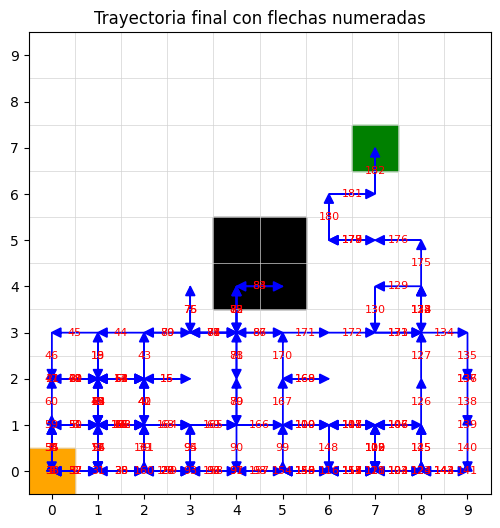

In [5]:
#==================================================================
# Movimiento completamente aleatorio
#==================================================================

#state = env.reset()
#state = tuple(env.reset(start=(2,0)))

done = False
while not done:
    action = env.action_space.sample()  # acción aleatoria
    state, reward, done, _ = env.step(action)

print("Trayectoria:", env.trajectory)
env.render_trajectory()

# **Q-Learning**

## Idea de Q-Learning

Se aprende una tabla:

$$
Q(s,a)
$$

con la actualización:

$$
Q(s,a) \leftarrow Q(s,a) + \alpha \left( r + \gamma \max_{a} Q(s',a) - Q(s,a) \right)
$$

In [6]:
#==================================================================
# Inicializar en ambiente
#==================================================================

# Inicializar entre (0,0) y (9,9)
env = GridRobotEnv()

# Inicializar definiiendo posicion inicial y/o final

#env = GridRobotEnv(start=(2,0), goal=(8,9))
#state = tuple(env.reset())

In [7]:
#==================================================================
# Inicializar la Q-table
#==================================================================

q_table = np.zeros((env.grid_size, env.grid_size, env.action_space.n)) # Dimensiones: estado = (x,y); acción = 4 posibles

In [8]:
#==================================================================
# Entrenamiento con Q-Learning
#==================================================================

alpha = 0.1      # learning rate
gamma = 0.9      # descuento
epsilon = 0.2    # exploración

episodes = 1000

for ep in range(episodes):
    state = tuple(env.reset())
    done = False
    
    steps = 0
    max_steps = 200  # IMPORTANTE (evita loops infinitos)
    
    while not done and steps < max_steps:
        
        # ε-greedy
        if np.random.rand() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(q_table[state])
        
        next_state, reward, done, _ = env.step(action)
        next_state = tuple(next_state)
        
        # Q-learning update
        q_table[state][action] += alpha * (
            reward + gamma * np.max(q_table[next_state]) - q_table[state][action]
        )
        
        state = next_state
        steps += 1
    
    # Decaimiento de epsilon (opcional)
    epsilon = max(0.01, epsilon * 0.995)

### Q-table completa

In [9]:
#print(q_table)

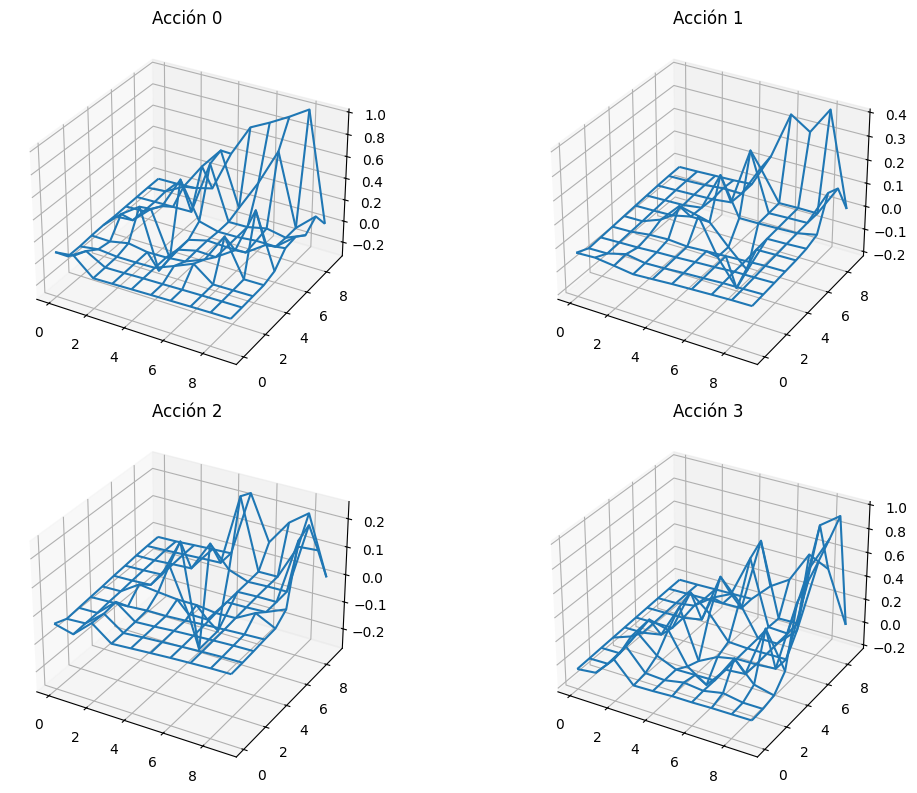

In [10]:
%matplotlib inline

x = np.arange(env.grid_size)
y = np.arange(env.grid_size)
X, Y = np.meshgrid(x, y)

fig = plt.figure(figsize=(12,8))

for a in range(4):
    ax = fig.add_subplot(2, 2, a+1, projection='3d')
    Z = q_table[:, :, a]
    
    ax.plot_wireframe(X, Y, Z)  # más ligero
    ax.set_title(f"Acción {a}")

plt.tight_layout()
plt.show()

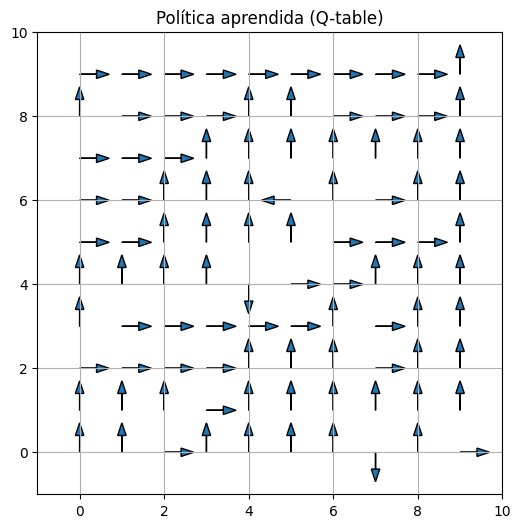

In [11]:
#import matplotlib.pyplot as plt

arrow_map = {
    0: (0, 0.4),   # arriba
    1: (0, -0.4),  # abajo
    2: (-0.4, 0),  # izquierda
    3: (0.4, 0)    # derecha
}

plt.figure(figsize=(6,6))

for x in range(env.grid_size):
    for y in range(env.grid_size):
        action = np.argmax(q_table[x, y])
        dx, dy = arrow_map[action]
        plt.arrow(x, y, dx, dy, head_width=0.2)

plt.xlim(-1, env.grid_size)
plt.ylim(-1, env.grid_size)
plt.grid()
plt.title("Política aprendida (Q-table)")
plt.show()

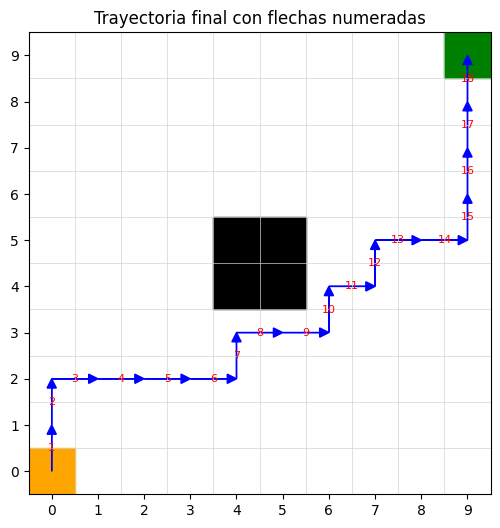

In [12]:
#==================================================================
# Evaluar la política aprendida
#==================================================================

state = tuple(env.reset())
done = False

steps = 0
max_steps = 200  # Limite de iteraciones para no caer en bucles

while not done and steps < max_steps:
    action = np.argmax(q_table[state])  # Política óptima
    state, reward, done, _ = env.step(action)
    state = tuple(state)
    steps += 1

env.render_trajectory()

In [13]:
#==================================================================
# Mostrar Q-table en cada paso
#==================================================================

state = tuple(env.reset())
done = False

steps = 0
max_steps = 10

print("[↑, ↓, ←, →]")

while not done and steps < max_steps :
    x, y = state
    
    # Imprimir valores Q del estado actual
    print(f"Paso {steps}: q_table[{x},{y}] = {q_table[x,y]}")
    
    # Elegir acción (política greedy)
    action = np.argmax(q_table[x, y])
    
    # Avanzar en el entorno
    state, reward, done, _ = env.step(action)
    state = tuple(state)
    
    steps += 1


[↑, ↓, ←, →]
Paso 0: q_table[0,0] = [ 0.083449   -0.02874335 -0.03528824 -0.0565831 ]
Paso 1: q_table[0,1] = [ 0.10383222 -0.02451943 -0.05229628 -0.0380198 ]
Paso 2: q_table[0,2] = [-0.04836545 -0.0339487   0.00816822  0.12648025]
Paso 3: q_table[1,2] = [-0.04400109 -0.02804275  0.00593156  0.15164472]
Paso 4: q_table[2,2] = [-0.03811432 -0.04275694  0.01276983  0.17960524]
Paso 5: q_table[3,2] = [-0.00469423 -0.0300815  -0.03790383  0.21067249]
Paso 6: q_table[4,2] = [ 0.24519166 -0.00656207  0.00671194 -0.00458568]
Paso 7: q_table[4,3] = [-0.30321326  0.07575162 -0.00107083  0.28354628]
Paso 8: q_table[5,3] = [-0.27824152 -0.01086816  0.06159573  0.32616254]
Paso 9: q_table[6,3] = [ 0.37351393 -0.01336836  0.1137696   0.00818681]


# SARSA

## Diferencia clave

### Q-Learning (off-policy)

$$
Q(s,a) \leftarrow Q(s,a) + \alpha \left( r + \gamma \max_{a} Q(s',a) - Q(s,a) \right)
$$

---

### SARSA (on-policy)

$$
Q(s,a) \leftarrow Q(s,a) + \alpha \left( r + \gamma Q(s',a') - Q(s,a) \right)
$$

---

**En SARSA:**

Se utiliza la acción realmente tomada \(a'\), no la mejor posible.

**En Q-Learning:**

Se utiliza la mejor acción posible (max), independientemente de la política seguida.

In [14]:
#==================================================================
# Inicializar en ambiente
#==================================================================

# Inicializar entre (0,0) y (9,9)
#env = GridRobotEnv()

# Inicializar definiiendo posicion inicial y/o final

env = GridRobotEnv(start=(2,0), goal=(8,9))
state = tuple(env.reset())


# Inicializar Q-table
q_table = np.zeros((env.grid_size, env.grid_size, env.action_space.n))

# Parámetros
alpha = 0.1       # learning rate
gamma = 0.99      # discount factor
epsilon = 0.1     # exploración
episodes = 500

def epsilon_greedy(state):
    if np.random.rand() < epsilon:
        return np.random.randint(4)
    else:
        return np.argmax(q_table[state])

# Entrenamiento SARSA
for ep in range(episodes):
    
    state = tuple(env.reset())
    action = epsilon_greedy(state)  # acción inicial
    
    done = False
    
    while not done:
        # Ejecutar acción
        next_state, reward, done, _ = env.step(action)
        next_state = tuple(next_state)
        
        # Elegir siguiente acción (clave en SARSA)
        next_action = epsilon_greedy(next_state)
        
        # Actualización SARSA
        q_table[state][action] += alpha * (
            reward + gamma * q_table[next_state][next_action] - q_table[state][action]
        )
        
        # Avanzar
        state = next_state
        action = next_action

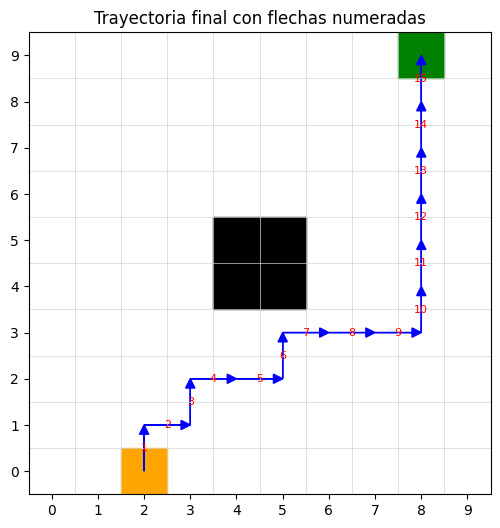

In [15]:
state = tuple(env.reset())
done = False

steps = 0
max_steps = 200

while not done and steps < max_steps:
    action = np.argmax(q_table[state])
    state, reward, done, _ = env.step(action)
    state = tuple(state)
    steps += 1

env.render_trajectory()

In [16]:
#==================================================================
# Mostrar Q-table en cada paso
#==================================================================

state = tuple(env.reset())
done = False

steps = 0
max_steps = 10

print("[↑, ↓, ←, →]")

while not done and steps < max_steps :
    x, y = state
    
    # Imprimir valores Q del estado actual
    print(f"Paso {steps}: q_table[{x},{y}] = {q_table[x,y]}")
    
    # Elegir acción (política greedy)
    action = np.argmax(q_table[x, y])
    
    # Avanzar en el entorno
    state, reward, done, _ = env.step(action)
    state = tuple(state)
    
    steps += 1

[↑, ↓, ←, →]
Paso 0: q_table[2,0] = [ 0.35475343  0.08059057 -0.05270694 -0.01297954]
Paso 1: q_table[2,1] = [0.01045007 0.11650922 0.01063997 0.35157341]
Paso 2: q_table[3,1] = [0.3910438  0.04781069 0.15058855 0.0890485 ]
Paso 3: q_table[3,2] = [-0.01689356  0.15254484  0.04235663  0.44236974]
Paso 4: q_table[4,2] = [0.02066569 0.13220526 0.10596222 0.45686166]
Paso 5: q_table[5,2] = [0.42211816 0.06398616 0.18260905 0.08414054]
Paso 6: q_table[5,3] = [-0.32142857  0.19894187  0.11971663  0.50998117]
Paso 7: q_table[6,3] = [0.15855485 0.10818698 0.14361931 0.56388577]
Paso 8: q_table[7,3] = [0.31052839 0.15735627 0.22676676 0.62200496]
Paso 9: q_table[8,3] = [0.73904556 0.11466534 0.33262369 0.29102504]


# **Deep Q-Learning (DQN)**

## DQN es una extensión de Q-Learning donde:

- en lugar de usar una tabla
- se usa una red neuronal para aproximar:

$$
Q(s,a;\theta)
$$

Es decir:

La red aprende cuánto vale tomar una acción $a$ en un estado $s$.

---

## Idea del algoritmo

En cada paso:

1. El agente observa el estado $s$  
2. Elige una acción $a$ (ε-greedy)  
3. Recibe recompensa $r$ y nuevo estado $s'$  
4. Ajusta la red para que:

$$
Q(s,a) \approx r + \gamma \max_{a} Q(s',a)
$$

## Entorno (GridRobotEnv)

Define el problema:

- **Estado:** posición \((x,y)\)  
- **Acciones:** ↑ ↓ ← →  

- **Recompensa:**
  - positiva en la meta  
  - negativa en obstáculos  
  - gradiente por distancia (clave)  

> Esto guía el aprendizaje

In [17]:
# ================================================================
# Entorno
# ================================================================
class GridRobotEnv(gym.Env):
    def __init__(self, grid_size=10, start=(0,0), goal=(9,9),
                 obstacles=[(4,4),(4,5),(5,4),(5,5)]):

        super().__init__()
        self.grid_size = grid_size
        self.start = start
        self.goal = goal
        self.obstacles = obstacles
        
        self.action_space = spaces.Discrete(4)
        self.observation_space = spaces.Box(low=0, high=grid_size-1,
                                            shape=(2,), dtype=np.int32)
        
        self.reset()
    
    def reset(self):
        self.state = self.start
        self.trajectory = [self.state]
        return np.array(self.state)
    
    def step(self, action):
        x, y = self.state
        
        if action == 0: y = min(y+1, self.grid_size-1)
        elif action == 1: y = max(y-1, 0)
        elif action == 2: x = max(x-1, 0)
        elif action == 3: x = min(x+1, self.grid_size-1)
        
        self.state = (x, y)
        self.trajectory.append(self.state)
        
        # ====================================================
        # Reward shaping (clave para que aprenda)
        # ====================================================
        goal_x, goal_y = self.goal
        dist = abs(x - goal_x) + abs(y - goal_y)
        
        reward = -0.01 - 0.01 * dist
        done = False
        
        if self.state == self.goal:
            reward = 10.0
            done = True
        
        elif self.state in self.obstacles:
            reward = -1.0
            done = True
        
        return np.array(self.state), reward, done, {}
    
    def render_trajectory(self):
        fig, ax = plt.subplots(figsize=(6,6))
        ax.set_xlim(-0.5, self.grid_size-0.5)
        ax.set_ylim(-0.5, self.grid_size-0.5)
        ax.set_aspect("equal")
        
        for i in range(self.grid_size):
            ax.axhline(i-0.5, color="lightgray", linewidth=0.5)
            ax.axvline(i-0.5, color="lightgray", linewidth=0.5)
        
        for (ox, oy) in self.obstacles:
            ax.add_patch(plt.Rectangle((ox-0.5, oy-0.5), 1, 1, color="black"))
        
        gx, gy = self.goal
        ax.add_patch(plt.Rectangle((gx-0.5, gy-0.5), 1, 1, color="green"))
        
        sx, sy = self.start
        ax.add_patch(plt.Rectangle((sx-0.5, sy-0.5), 1, 1, color="orange"))
        
        for (x0,y0), (x1,y1) in zip(self.trajectory[:-1], self.trajectory[1:]):
            dx, dy = x1-x0, y1-y0
            ax.arrow(x0, y0, dx*0.8, dy*0.8, head_width=0.2, fc="blue")
        
        plt.title("Trayectoria aprendida")
        plt.show()

## Red neuronal (DQN)

$$
\text{nn.Linear}(2 \rightarrow 64 \rightarrow 64 \rightarrow 4)
$$

- **Entrada:** estado $(x,y)$  
- **Salida:** valores $Q(s,a)$ para cada acción  

> Reemplaza la Q-table

In [18]:
# ================================================================
# Red DQN
# ================================================================
class DQN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 4)
        )
    
    def forward(self, x):
        return self.net(x)

## Replay Buffer

**buffer.add((s, a, r, s', done))**

Guarda experiencias pasadas.

> Se entrena con muestras aleatorias:

- rompe correlación temporal
- estabiliza aprendizaje

In [19]:
# ================================================================
# Replay Buffer
# ================================================================
class ReplayBuffer:
    def __init__(self, capacity=5000):
        self.buffer = []
        self.capacity = capacity
    
    def add(self, transition):
        if len(self.buffer) >= self.capacity:
            self.buffer.pop(0)
        self.buffer.append(transition)
    
    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        return (
            np.array([b[0] for b in batch]),
            np.array([b[1] for b in batch]),
            np.array([b[2] for b in batch]),
            np.array([b[3] for b in batch]),
            np.array([b[4] for b in batch])
        )

## Target Network

**target_model.load_state_dict(model.state_dict())**

- Copia de la red principal

- Se actualiza cada cierto tiempo

> Evita inestabilidad

In [20]:
# ================================================================
# Inicialización
# ================================================================
env = GridRobotEnv()

model = DQN()
target_model = DQN()
target_model.load_state_dict(model.state_dict())

optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

buffer = ReplayBuffer()

gamma = 0.99
epsilon = 1.0
epsilon_min = 0.05
epsilon_decay = 0.995

episodes = 1000
batch_size = 32

## Entrenamiento (DQN)

$$
\text{target} = r + \gamma \max_a Q_{\text{target}}(s')
$$

- Calcula el objetivo  
- Minimiza error (MSE)  
> La red aprende a aproximar la ecuación de Bellman

In [21]:
# ================================================================
# Entrenamiento
# ================================================================
step_count = 0

for ep in range(episodes):
    state = env.reset()
    done = False
    
    steps = 0
    max_steps = 100
    
    while not done and steps < max_steps:
        
        step_count += 1
        
        # ε-greedy
        if np.random.rand() < epsilon:
            action = np.random.randint(4)
        else:
            state_t = torch.FloatTensor(state).unsqueeze(0)
            action = torch.argmax(model(state_t)).item()
        
        next_state, reward, done, _ = env.step(action)
        
        buffer.add((state, action, reward, next_state, done))
        state = next_state
        
        # Entrenamiento cada 4 pasos
        if len(buffer.buffer) >= batch_size and step_count % 4 == 0:
            
            states, actions, rewards, next_states, dones = buffer.sample(batch_size)
            
            states = torch.FloatTensor(states)
            actions = torch.LongTensor(actions)
            rewards = torch.FloatTensor(rewards)
            next_states = torch.FloatTensor(next_states)
            dones = torch.FloatTensor(dones)
            
            q_values = model(states)
            next_q_values = target_model(next_states)
            
            q_value = q_values.gather(1, actions.unsqueeze(1)).squeeze()
            next_q_value = torch.max(next_q_values, dim=1)[0]
            
            target = rewards + gamma * next_q_value * (1 - dones)
            
            loss = loss_fn(q_value, target.detach())
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        
        steps += 1
    
    # actualizar target network
    if ep % 10 == 0:
        target_model.load_state_dict(model.state_dict())
    
    # epsilon decay
    # empieza explorando
    # termina siendo óptimo
    epsilon = max(epsilon_min, epsilon * epsilon_decay)
    
    if (ep + 1) % 50 == 0:
        print(f"Episodio {ep+1}/{episodes} - epsilon={epsilon:.3f}")

Episodio 50/1000 - epsilon=0.778
Episodio 100/1000 - epsilon=0.606
Episodio 150/1000 - epsilon=0.471
Episodio 200/1000 - epsilon=0.367
Episodio 250/1000 - epsilon=0.286
Episodio 300/1000 - epsilon=0.222
Episodio 350/1000 - epsilon=0.173
Episodio 400/1000 - epsilon=0.135
Episodio 450/1000 - epsilon=0.105
Episodio 500/1000 - epsilon=0.082
Episodio 550/1000 - epsilon=0.063
Episodio 600/1000 - epsilon=0.050
Episodio 650/1000 - epsilon=0.050
Episodio 700/1000 - epsilon=0.050
Episodio 750/1000 - epsilon=0.050
Episodio 800/1000 - epsilon=0.050
Episodio 850/1000 - epsilon=0.050
Episodio 900/1000 - epsilon=0.050
Episodio 950/1000 - epsilon=0.050
Episodio 1000/1000 - epsilon=0.050


## Evaluación (DQN)

**action = argmax Q(s)**

> Ya no hay exploración

> Sigue la política aprendida

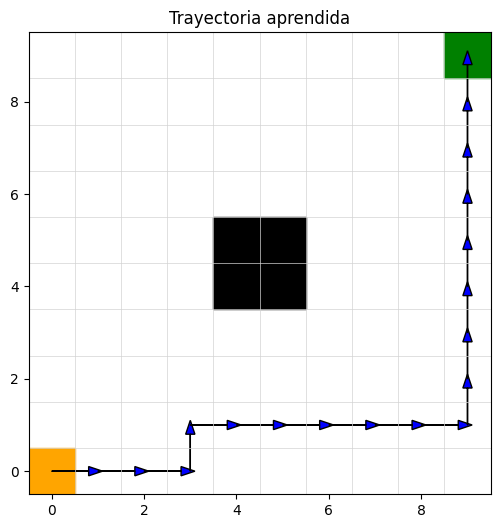

In [23]:
# ================================================================
# Evaluación
# ================================================================
state = env.reset()
done = False

steps = 0
max_steps = 100

while not done and steps < max_steps:
    state_t = torch.FloatTensor(state).unsqueeze(0)
    action = torch.argmax(model(state_t)).item()
    
    state, reward, done, _ = env.step(action)
    steps += 1

env.render_trajectory()

# **Dyna-Q**

**Dyna-Q** es básicamente una extensión de **Q-learning**, combinando aprendizaje por experiencia directa con planificación basada en un modelo. 

## Q-learning clásico
- Aprende la función $Q(s,a)$ directamente de las interacciones con el entorno real.  
- Actualización típica:

$$
Q(s,a) \gets Q(s,a) + \alpha \Big[ r + \gamma \max_{a'} Q(s',a') - Q(s,a) \Big]
$$

- Solo se aprende de experiencias reales $(s,a,r,s')$.

---

## Dyna-Q
Combina Q-learning + planificación:

- **Aprendizaje por experiencia real:** igual que Q-learning, se actualiza $Q(s,a)$ con la transición real.
- **Actualización del modelo:** guarda $(s,a) \rightarrow (r,s')$ en un diccionario.
- **Planificación:** toma algunas transiciones simuladas del modelo y actualiza $Q(s,a)$ como si esas transiciones ocurrieran realmente.

Resumiendo:

$$
\text{Dyna-Q} = \text{Q-learning} + \text{Modelo interno para simular experiencias}
$$

> Esto acelera el aprendizaje, porque no depende solo de la interacción con el entorno real: puede “practicar” con el modelo interno.

In [24]:
#==================================================================
# Define un entorno
#==================================================================

class GridRobotEnv(gym.Env):
    def __init__(self, grid_size=10, start=(0,0), goal=(9,9), obstacles=[(4,4),(4,5),(5,4),(5,5)]):
        super().__init__()
        self.grid_size = grid_size       # tamaño de la grilla (10x10)
        self.start = start               # posición inicial
        self.goal = goal                 # objetivo
        self.obstacles = obstacles       # celdas prohibidas
        self.state = self.start          # Estado del entorno s=(x,y)
        self.trajectory = [self.start]   # guarda posiciones visitadas
        
        # Posibes acciones: 0=arriba, 1=abajo, 2=izq, 3=der
        self.action_space = spaces.Discrete(4)
        # Estado: posición (x,y)
        self.observation_space = spaces.Box(low=0, high=grid_size-1, shape=(2,), dtype=np.int32)
    
    # def reset(self):                    # Reinicia el entorno
    #     self.state = self.start         # Vuelve al inicio
    #     self.trajectory = [self.start]  # Limpia la trayectoria
    #     return np.array(self.state)

    # def reset(self, start=None):
    #     if start is not None:
    #         self.start = start
    #     self.state = self.start
    #     self.trajectory = [self.state]
    #     return np.array(self.state)

    def reset(self, start=None, goal=None):
        if start is not None:
            self.start = start
        if goal is not None:
            self.goal = goal

        self.state = self.start
        self.trajectory = [self.state]
        return np.array(self.state)

    
    def step(self, action):
        x,y = self.state
        if action==0: y = min(y+1,self.grid_size-1) # Mueve el robot en la grilla respetando límites
        elif action==1: y = max(y-1,0)
        elif action==2: x = max(x-1,0)
        elif action==3: x = min(x+1,self.grid_size-1)

        # Actualiza estado
        self.state = (x,y)
        self.trajectory.append(self.state)  # guardar trayectoria
        
        # Recompensa
        reward = -0.01 # Penaliza cada paso → incentiva caminos cortos
        done = False
        
        if self.state == self.goal: # Caso 1: llega a la meta
            reward = 1.0
            done = True
        elif self.state in self.obstacles: # Caso 2: cae en obstáculo
            reward = -0.5 # en vez de -1 
            #done = True
            done = False  # permitir continuar
            
        return np.array(self.state), reward, done, {}
    
    def render_trajectory(self):
        """Muestra la trayectoria final con flechas numeradas."""
        fig, ax = plt.subplots(figsize=(6,6))
        ax.set_xlim(-0.5, self.grid_size-0.5)
        ax.set_ylim(-0.5, self.grid_size-0.5)
        ax.set_aspect("equal")
        
        # Dibujar grilla
        for i in range(self.grid_size):
            ax.axhline(i-0.5, color="lightgray", linewidth=0.5)
            ax.axvline(i-0.5, color="lightgray", linewidth=0.5)
        
        # Obstáculos
        for (ox, oy) in self.obstacles:
            ax.add_patch(plt.Rectangle((ox-0.5, oy-0.5), 1, 1, color="black"))
        
        # Meta
        gx, gy = self.goal
        ax.add_patch(plt.Rectangle((gx-0.5, gy-0.5), 1, 1, color="green"))
        
        # Inicio
        sx, sy = self.start
        ax.add_patch(plt.Rectangle((sx-0.5, sy-0.5), 1, 1, color="orange"))
        
        # Dibujar trayectoria con flechas numeradas
        for step_idx, ((x0,y0), (x1,y1)) in enumerate(zip(self.trajectory[:-1], self.trajectory[1:]), start=1):
            dx, dy = x1-x0, y1-y0
            ax.arrow(x0, y0, dx*0.8, dy*0.8, 
                     head_width=0.2, head_length=0.2, 
                     fc="blue", ec="blue")
            # Colocar número en el centro de la flecha
            ax.text(x0+dx*0.5, y0+dy*0.5, str(step_idx),
                    color="red", fontsize=8, ha="center", va="center")
        
        ax.set_xticks(range(self.grid_size))
        ax.set_yticks(range(self.grid_size))
        ax.set_title("Trayectoria final con flechas numeradas")
        plt.show()

In [25]:
#==================================================================
# Agente Dyna-Q
#==================================================================
class DynaQAgent:
#-----------------------------------------------------------------    
    # Inicializacion
    def __init__(self, env, alpha=0.1, gamma=0.95, epsilon=0.1, planning_steps=10):
        self.env = env
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.planning_steps = planning_steps
        
        self.grid_size = env.grid_size
        self.n_states = env.grid_size * env.grid_size
        self.n_actions = env.action_space.n
        
        # Q-table
        self.Q = np.zeros((self.n_states, self.n_actions))
        # Modelo para planificación
        self.model = {}

#-----------------------------------------------------------------    
    # Función Estado a indice
        # Convierte el estado (x,y) en un índice único para acceder a la Q-table.
        # Esto es necesario porque Q es un arreglo 2D n_states × n_actions, no una matriz de tuplas.
    def state_to_index(self, state):
        x, y = state
        return x * self.grid_size + y


#-----------------------------------------------------------------    
    # Selección de acción
    #     Implementa política ε-greedy:
    #          Explora con probabilidad epsilon.
    #          Explota siguiendo la mejor acción según la Q-table.
    def choose_action(self, state):
        s_idx = self.state_to_index(state)
        if random.random() < self.epsilon: 
            return self.env.action_space.sample()  # acción aleatoria (exploración)
        else:
            return int(np.argmax(self.Q[s_idx]))  # acción con mayor valor Q (explotación)

#-----------------------------------------------------------------    
    # Aprendizaje
        # El agente entrena por un número de episodios.
        # Cada episodio empieza desde el estado inicial.
    def learn(self, episodes=300):
        for ep in range(episodes):
            state = self.env.reset()
            done = False
            steps = 0

            #-----------------------------------------------------------------    
            # a) Interacción con el entorno
            while not done:
                # Paso clásico de Q-learning:
                # Observa (state, action, reward, next_state).
                s_idx = self.state_to_index(state)
                action = self.choose_action(state)
                next_state, reward, done, _ = self.env.step(action)
                ns_idx = self.state_to_index(next_state)
                

                #-----------------------------------------------------------------    
                # Actualiza Q-table para mejorar la estimación del valor de la acción.
                self.Q[s_idx, action] += self.alpha * (reward + self.gamma * np.max(self.Q[ns_idx]) - self.Q[s_idx, action])


            #-----------------------------------------------------------------    
            # b) Actualización del modelo
                    # Guarda la transición en el modelo interno.
                    # Permite que el agente haga planificación interna sin interactuar con el entorno real.
                self.model[(s_idx, action)] = (reward, ns_idx)
                
            #-----------------------------------------------------------------    
            # c) Planificación interna (simulación)
                # Selecciona aleatoriamente experiencias pasadas del modelo.
                # Actualiza Q como si esas transiciones ocurrieran realmente.
                # Esto acelera el aprendizaje, porque el agente “practica en su cabeza” antes de intentar nuevas acciones en el entorno real.
                for _ in range(self.planning_steps):
                    (s_pl, a_pl), (r_pl, ns_pl) = random.choice(list(self.model.items()))
                    self.Q[s_pl, a_pl] += self.alpha * (r_pl + self.gamma * np.max(self.Q[ns_pl]) - self.Q[s_pl, a_pl])
                
                state = next_state
                steps += 1
            
            if (ep+1) % 20 == 0:
                print(f"Episodio {ep+1}, pasos: {steps}")

#-----------------------------------------------------------------    
    # Extracción de la ruta
        # Usa la Q-table ya aprendida para seguir la política óptima desde el inicio hasta la meta.
        # Convierte state y next_state a tuplas para evitar errores de comparación con arrays.
        # Guarda la trayectoria visitada en self.env.trajectory para luego visualizar el camino con render_trajectory().
    def extract_path(self, max_steps=100):
        state = tuple(self.env.reset())
        self.env.trajectory = [state]
        for _ in range(max_steps):
            s_idx = self.state_to_index(state)
            action = int(np.argmax(self.Q[s_idx]))
            next_state, _, done, _ = self.env.step(action)
            next_state = tuple(next_state)  # <-- convertir a tupla
            if next_state == state:          # evita loop infinito si se queda atascado
                break
            state = next_state
            if done:
                break
        return self.env.trajectory

In [26]:
#==================================================================
# Entrenamiento
#==================================================================
env = GridRobotEnv()                            # Instancia (crea) el entorno
agent = DynaQAgent(env, planning_steps=10)      # Instancia el agente. Cada paso real genera 10 simulaciones internas usando el modelo.
agent.learn(episodes=300)                       # El agente entrena durante 300 episodios.
                                                    # En cada episodio:
                                                        # Se reinicia el entorno (env.reset()).
                                                        # El agente elige acciones con política ε-greedy.
                                                        # Actualiza la Q-table con la experiencia real (s,a,r,s').
                                                        # Guarda la transición en el modelo interno (s,a) → (r,s').
                                                        # Realiza planning_steps actualizaciones adicionales usando experiencias simuladas del modelo.
                                                    # Cada 20 episodios imprime el número de pasos del episodio para monitorizar el progreso. 

Episodio 20, pasos: 22
Episodio 40, pasos: 19
Episodio 60, pasos: 18
Episodio 80, pasos: 22
Episodio 100, pasos: 20
Episodio 120, pasos: 20
Episodio 140, pasos: 20
Episodio 160, pasos: 22
Episodio 180, pasos: 20
Episodio 200, pasos: 22
Episodio 220, pasos: 18
Episodio 240, pasos: 18
Episodio 260, pasos: 26
Episodio 280, pasos: 20
Episodio 300, pasos: 18


Trayectoria encontrada: [(0, 0), (1, 0), (1, 1), (2, 1), (3, 1), (3, 2), (3, 3), (3, 4), (3, 5), (3, 6), (4, 6), (5, 6), (6, 6), (6, 7), (6, 8), (7, 8), (8, 8), (9, 8), (9, 9)]


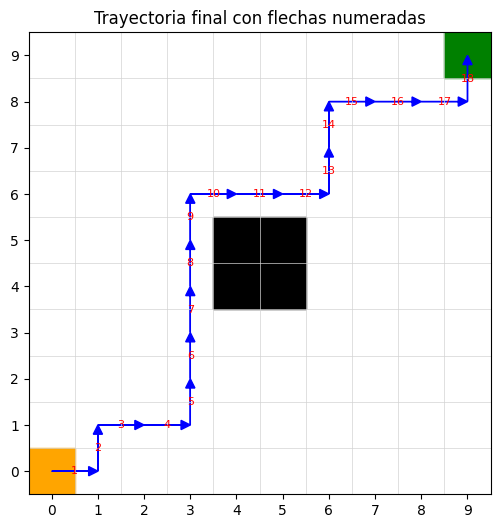

In [27]:
#==================================================================
# Visualización
#==================================================================
# Extrae la trayectoria óptima
    # Usa la Q-table ya aprendida para seguir la política óptima desde el inicio hasta la meta.
    
trajectory = agent.extract_path()
print("Trayectoria encontrada:", trajectory)

# Mostrar trayectoria con flechas
env.render_trajectory()

# **REINFORCE**

**REINFORCE** es un algoritmo de **policy gradient** en aprendizaje por refuerzo que aprende directamente una **política parametrizada** $\pi_\theta(a|s)$.  
Se actualiza usando episodios completos y el **gradiente de la probabilidad de las acciones** ponderado por el **retorno** $G_t$:

$$
\theta \leftarrow \theta + \alpha \, G_t \, \nabla_\theta \log \pi_\theta(a_t|s_t)
$$

- Tipo: basado en política (no value-based).  
- Aprende una política probabilística directamente desde la interacción con el entorno.  
- No requiere un modelo del entorno.

## Diferencias clave entre Q-learning / Dyna-Q y REINFORCE

| Aspecto | Q-learning / Dyna-Q | REINFORCE |
|---------|-------------------|------------|
| Tipo de algoritmo | Basado en valores (value-based) | Basado en política (policy gradient) |
| Qué aprende | Función Q(s,a) | Política $\pi_\theta(a|s)$ |
| Acción de exploración | ε-greedy | Exploración natural de la política probabilística |
| Necesita modelo del entorno | No (Dyna-Q usa modelo interno para planificación opcional) | No, se aprende desde la interacción real |

---

### Flujo básico con REINFORCE

1. Inicializar la política $\pi_\theta(a|s)$.  
2. Por cada episodio:
   - Generar un **episodio completo** siguiendo $\pi_\theta$.  
   - Para cada paso $t$ en el episodio, actualizar los parámetros de la política:

$$
\theta \leftarrow \theta + \alpha \, G_t \, \nabla_\theta \log \pi_\theta(a_t|s_t)
$$

3. Repetir hasta convergencia.

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces

In [35]:
# --------------------------------------------------------
# ENTORNO
# --------------------------------------------------------
# Constructor __init__:
    # grid_size → tamaño del grid (10x10).
    # start y goal → posición inicial y meta.
    # obstacles → posiciones bloqueadas.
    # action_space → 4 acciones discretas (arriba, abajo, izquierda, derecha).
    # observation_space → el estado es un vector [x,y] dentro del grid.

class GridRobotEnv(gym.Env):
    def __init__(self, grid_size=10, start=(0,0), goal=(9,9),
                 obstacles=[(4,4),(4,5),(5,4),(5,5)]):
        super().__init__()
        self.grid_size = grid_size
        self.start = start
        self.goal = goal
        self.obstacles = obstacles
        self.state = self.start
        self.trajectory = []

        # Acción: 0=arriba,1=abajo,2=izq,3=der
        self.action_space = spaces.Discrete(4)
        self.observation_space = spaces.Box(low=0, high=grid_size-1,
                                            shape=(2,), dtype=np.int32)

# Método reset():
    # Reinicia el estado del agente y la trayectoria.
    # Devuelve el estado inicial.
    
    def reset(self):
        self.state = self.start
        self.trajectory = [self.state]
        return np.array(self.state)


# Método step(action):
    # Actualiza la posición según la acción elegida.
    # Verifica si el nuevo estado es la meta (done=True) o un obstáculo.
    # Asigna recompensas:
        # 10 si llega a la meta
        # -10 si choca con obstáculo
        # -0.01 por cada paso para incentivar caminos más cortos
    
    def step(self, action):
        x, y = self.state
        if action == 0:  # arriba
            y = min(y + 1, self.grid_size - 1)
        elif action == 1:  # abajo
            y = max(y - 1, 0)
        elif action == 2:  # izq
            x = max(x - 1, 0)
        elif action == 3:  # der
            x = min(x + 1, self.grid_size - 1)

        self.state = (x, y)
        self.trajectory.append(self.state)

        reward = -0.01
        done = False
        if self.state == self.goal:
            reward = 10.0
            done = True
        elif self.state in self.obstacles:
            reward = -10.0
            done = True

        return np.array(self.state), reward, done, {}

# Método render_trajectory():
    # Dibuja la cuadrícula, obstáculos, inicio, meta y la trayectoria final con flechas numeradas.

    def render_trajectory(self):
        fig, ax = plt.subplots(figsize=(6,6))
        ax.set_xlim(-0.5, self.grid_size-0.5)
        ax.set_ylim(-0.5, self.grid_size-0.5)
        ax.set_xticks(np.arange(-0.5, self.grid_size, 1))
        ax.set_yticks(np.arange(-0.5, self.grid_size, 1))
        ax.grid(True)

        # Obstáculos
        for ox, oy in self.obstacles:
            ax.add_patch(plt.Rectangle((ox-0.5, oy-0.5), 1, 1, color="black"))

        # Inicio y meta
        ax.text(self.start[0], self.start[1], "S",
                ha="center", va="center", fontsize=14, color="blue")
        ax.text(self.goal[0], self.goal[1], "G",
                ha="center", va="center", fontsize=14, color="green")

        # Trayectoria con flechas numeradas
        for i in range(len(self.trajectory)-1):
            x0, y0 = self.trajectory[i]
            x1, y1 = self.trajectory[i+1]
            if (x0,y0) != (x1,y1):  # dibujar solo si realmente se mueve
                ax.annotate(str(i+1),
                            xy=(x1, y1), xycoords='data',
                            xytext=(x0, y0), textcoords='data',
                            arrowprops=dict(arrowstyle="->", lw=1.5, color="red"),
                            ha="center", va="center", fontsize=10, color="red")

        plt.title("Trayectoria Final con REINFORCE")
        plt.show()

In [36]:
# --------------------------------------------------------
# Función softmax
# --------------------------------------------------------
# Convierte un vector de valores (parámetros theta) en probabilidades de acción.
# Garantiza que la suma sea 1 y evita overflow con - np.max(x).
# Se usa para elegir acciones de manera estocástica.


def softmax(x):
    e_x = np.exp(x - np.max(x))
    return e_x / e_x.sum()

In [37]:
# --------------------------------------------------------
# Algoritmo REINFORCE
#    Implementa REINFORCE puro para políticas discretas.
# --------------------------------------------------------

# Parámetros de la política theta:
    # theta[x,y,a] → representa la preferencia por acción a en la posición (x,y).
    # Inicialmente todos ceros → política uniforme.

def run_reinforce(env, episodes=1000, gamma=0.99, alpha=0.01, max_steps=200):
    theta = np.zeros((env.grid_size, env.grid_size, env.action_space.n))
    rewards_all, steps_all, success_all = [], [], []

    # Loop de episodios:Usa softmax para convertir preferencias en probabilidades.
        # Reinicia el entorno.
        # Guarda la trayectoria (estado, acción, recompensa) de cada episodio.
    for ep in range(episodes):
        state = env.reset()
        traj = []
        total_r = 0
        success = 0

        # Selección de acción:
        for t in range(max_steps):
            x,y = state
            probs = softmax(theta[x,y,:]) # Usa softmax para convertir preferencias en probabilidades.
            action = np.random.choice(env.action_space.n, p=probs) # Acción muestreada estocásticamente → exploración.

            next_state, reward, done, _ = env.step(action)
            traj.append((state, action, reward))
            total_r += reward
            state = next_state

            if done:
                if tuple(state) == env.goal:
                    success = 1
                break

        # Calcular retornos G_t
        G = 0
        returns = []
        for (_, _, r) in reversed(traj):
            G = r + gamma*G     # Recompensa acumulada desde cada paso, considerando el factor de descuento gamma.
            returns.insert(0, G)

        # Actualizar parámetros theta
        for i, (s,a,_) in enumerate(traj):
            x,y = s
            probs = softmax(theta[x,y,:])
            baseline = np.dot(probs, theta[x,y,:])       # Baseline opcional → reduce varianza.
            advantage = returns[i] - baseline            # Cuánto mejor fue la acción respecto al baseline.
            grad = -probs                                # Gradiente para política estocástica.
            grad[a] += 1.0
            theta[x,y,:] += alpha * advantage * grad     # Actualización paso a paso usando tasa de aprendizaje alpha.


        # Métricas:
        rewards_all.append(total_r)      # rewards_all → recompensa total por episodio.
        steps_all.append(len(traj))      # steps_all → número de pasos por episodio.
        success_all.append(success)      # success_all → 1 si llegó a la meta, 0 si no.

    return theta, rewards_all, steps_all, success_all

In [38]:
# --------------------------------------------------------
# ENTRENAMIENTO
# --------------------------------------------------------
env = GridRobotEnv()  # Se instancia el entorno
theta, rewards, steps, success = run_reinforce(env, episodes=1800) # lama a la función run_reinforce para entrenar la política del agente.

Evaluación final: pasos=18, llegó_meta=True, done=True


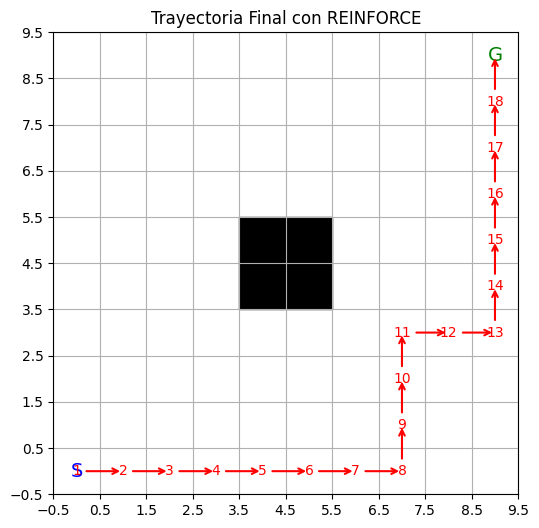

In [39]:
# --------------------------------------------------------
# EVALUACIÓN (greedy con límite de pasos)
# --------------------------------------------------------
# Reiniciar el entorno y preparar variables
state = env.reset()
done = False
max_steps = 200
steps_eval = 0

# Loop de evaluación (acción greedy)
while not done and steps_eval < max_steps:
    x,y = state
    probs = softmax(theta[x,y,:])
    action = np.argmax(probs)  # política determinista greedy
    state, reward, done, _ = env.step(action)
    steps_eval += 1

# Imprimir resultados de la evaluación
print(f"Evaluación final: pasos={steps_eval}, llegó_meta={tuple(state)==env.goal}, done={done}")
env.render_trajectory()


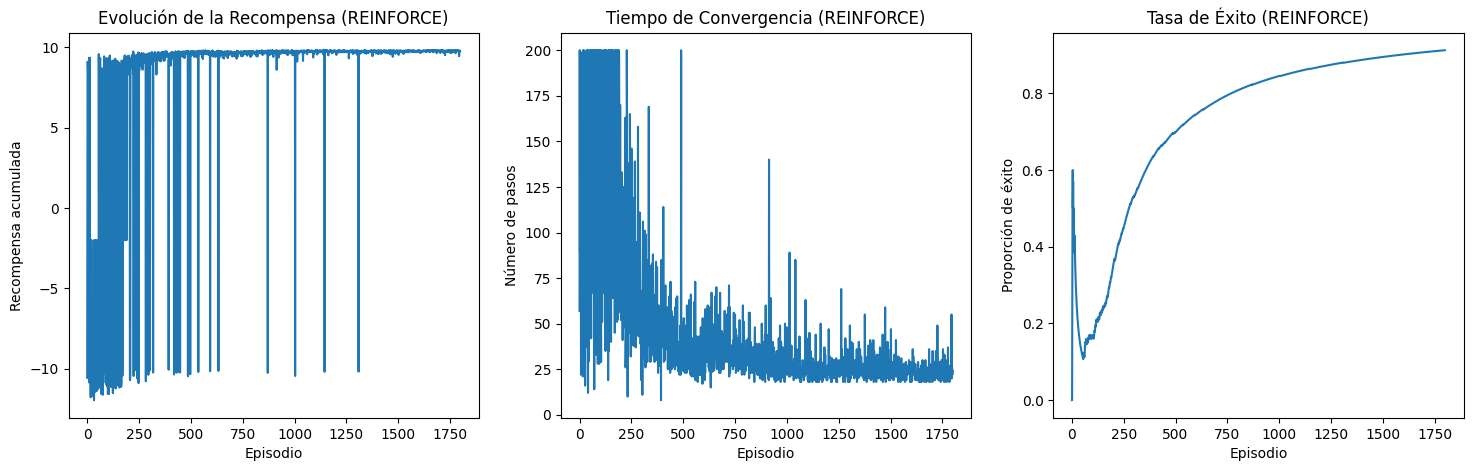

In [40]:
# --------------------------------------------------------
# GRAFICAR MÉTRICAS
# --------------------------------------------------------
fig, axs = plt.subplots(1,3, figsize=(18,5))

axs[0].plot(rewards)
axs[0].set_title("Evolución de la Recompensa (REINFORCE)")
axs[0].set_xlabel("Episodio")
axs[0].set_ylabel("Recompensa acumulada")

axs[1].plot(steps)
axs[1].set_title("Tiempo de Convergencia (REINFORCE)")
axs[1].set_xlabel("Episodio")
axs[1].set_ylabel("Número de pasos")

axs[2].plot(np.cumsum(success)/np.arange(1,len(success)+1))
axs[2].set_title("Tasa de Éxito (REINFORCE)")
axs[2].set_xlabel("Episodio")
axs[2].set_ylabel("Proporción de éxito")

plt.show()

# **Actor-Critic**

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces

### Actor-Critic en Reinforcement Learning

La técnica **Actor-Critic** combina dos enfoques fundamentales del aprendizaje por refuerzo:

- **Actor (política $\pi_\theta(a \mid s)$)**:  
  Se encarga de seleccionar acciones en función del estado actual. Es un modelo parametrizado (por $\theta$) que aprende directamente la política.

- **Critic (función de valor $V(s)$ o $Q(s,a)$)**:  
  Evalúa qué tan buena es la acción tomada por el Actor, estimando el valor de los estados o pares estado-acción.

---

### Idea clave

El **Actor aprende de las críticas del Critic**:

1. El agente ejecuta una acción según la política.
2. El Critic calcula el error de predicción (error TD):
   $$\delta = r + \gamma V(s') - V(s)$$
3. Este error se usa para:
   - Actualizar el **Critic** (mejorar la estimación de valor)
   - Ajustar el **Actor** (reforzar acciones buenas y penalizar malas)

---

### Ventajas

- Reduce la varianza de métodos puramente basados en política (como REINFORCE)
- Aprende de manera más estable y eficiente
- Permite trabajar con espacios de acción grandes o continuos

In [13]:
# --------------------------------------------------------
# HIPERPARÁMETROS
# --------------------------------------------------------
EPISODES     = 2000   # número de episodios
GAMMA        = 0.99   # factor de descuento
ALPHA_THETA  = 0.05   # tasa de aprendizaje del actor
ALPHA_V      = 0.1    # tasa de aprendizaje del crítico
MAX_STEPS    = 200    # pasos máximos por episodio
TAU_TRAIN    = 1.0    # temperatura softmax (exploración)
TAU_EVAL     = 0.1    # temperatura softmax en evaluación (explotación)

In [14]:
# --------------------------------------------------------
# MISMO ENTORNO QUE ANTES
# --------------------------------------------------------
class GridRobotEnv(gym.Env):
    def __init__(self, grid_size=10, start=(0,0), goal=(9,9),
                 obstacles=[(4,4),(4,5),(5,4),(5,5)]):
        super().__init__()
        self.grid_size = grid_size
        self.start = start
        self.goal = goal
        self.obstacles = obstacles
        self.state = self.start
        self.trajectory = []

        # Acción: 0=arriba,1=abajo,2=izq,3=der
        self.action_space = spaces.Discrete(4)
        self.observation_space = spaces.Box(
            low=0, high=grid_size-1, shape=(2,), dtype=np.int32)

    def reset(self):
        self.state = self.start
        self.trajectory = [self.state]
        return np.array(self.state)

    def step(self, action):
        x,y = self.state
        if action==0: y = min(y+1,self.grid_size-1)
        elif action==1: y = max(y-1,0)
        elif action==2: x = max(x-1,0)
        elif action==3: x = min(x+1,self.grid_size-1)

        self.state = (x,y)
        self.trajectory.append(self.state)

        reward = -0.01
        done = False

        if self.state == self.goal:
            reward = 20.0   # recompensa más fuerte para guiar el aprendizaje
            done = True
        elif self.state in self.obstacles:
            reward = -5.0   # penalización más fuerte
            done = True

        return np.array(self.state), reward, done, {}

    def render_trajectory(self, trajectory=None):
        fig, ax = plt.subplots(figsize=(6,6))
        ax.set_xlim(-0.5, self.grid_size-0.5)
        ax.set_ylim(-0.5, self.grid_size-0.5)
        ax.set_xticks(np.arange(-0.5, self.grid_size, 1))
        ax.set_yticks(np.arange(-0.5, self.grid_size, 1))
        ax.grid(True)

        # Obstáculos
        for ox, oy in self.obstacles:
            ax.add_patch(plt.Rectangle((ox-0.5, oy-0.5), 1, 1, color="black"))

        # Inicio y meta
        ax.text(self.start[0], self.start[1], "S", ha="center", va="center",
                fontsize=14, color="blue")
        ax.text(self.goal[0], self.goal[1], "G", ha="center", va="center",
                fontsize=14, color="green")

        # Trayectoria con flechas numeradas
        trj = trajectory if trajectory is not None else self.trajectory
        for i in range(len(trj)-1):
            x0, y0 = trj[i]
            x1, y1 = trj[i+1]
            ax.annotate(str(i+1),
                        xy=(x1, y1), xycoords='data',
                        xytext=(x0, y0), textcoords='data',
                        arrowprops=dict(arrowstyle="->", lw=1.5, color="red"),
                        ha="center", va="center", fontsize=10, color="red")

        plt.title("Trayectoria Final con Actor-Critic")
        plt.show()

In [15]:
# --------------------------------------------------------
# Función softmax para convertir valores en probabilidades.
# --------------------------------------------------------
def softmax(x, tau=1.0):
    z = x - np.max(x)
    exp_z = np.exp(z / tau)
    return exp_z / np.sum(exp_z)

### Entrenamiento Actor-Critic

Se entrena un agente utilizando dos componentes principales:

- **Actor** → Política  $\pi(a \mid s)$ representada por $\theta$

- **Critic** → Función de valor  $V(s)$

El proceso de entrenamiento permite que:
- El **Actor** aprenda qué acción tomar en cada estado.
- El **Critic** evalúe qué tan bueno es un estado bajo la política actual.

---
### Salidas del entrenamiento

El algoritmo devuelve:

- **Política aprendida**: $\theta$  
- **Función de valor**: $V(s)$  
- **Métricas de entrenamiento**:
  - Recompensas acumuladas
  - Número de pasos por episodio
  - Tasa de éxito

In [16]:
# --------------------------------------------------------
# Actor-Critic
# --------------------------------------------------------
def run_actor_critic(env, episodes=EPISODES, gamma=GAMMA,
                     alpha_theta=ALPHA_THETA, alpha_v=ALPHA_V,
                     max_steps=MAX_STEPS, tau=TAU_TRAIN):

    # Inicialización
    theta = np.zeros((env.grid_size, env.grid_size, env.action_space.n))  # política
    V = np.zeros((env.grid_size, env.grid_size))                          # valores
    rewards, steps, success = [], [], []

    # Loop de episodios
    for ep in range(episodes):
        state = env.reset()
        done = False
        total_r, step_count, reached = 0, 0, 0
        x,y = state

        while not done and step_count < max_steps:
            # Selección de acción (Actor)
            probs = softmax(theta[x,y,:], tau)
            action = np.random.choice(env.action_space.n, p=probs)
            
            # Interacción con el entorno
            next_state, reward, done, _ = env.step(action)
            nx,ny = next_state

            # TD error, corresponde a: 𝛿 = 𝑟 + 𝛾 𝑉(𝑠′) − 𝑉(𝑠). 
            td_target = reward + (0 if done else gamma*V[nx,ny])
            delta = td_target - V[x,y]     # Delta mide qué tan buena fue la acción

            # Actualizar crítico
                # Ajusta el valor del estado
                # Aprende a estimar 𝑉(𝑠)
            V[x,y] += alpha_v * delta

            # Actualizar actor
            grad = -probs       # grad ≈ gradiente de log-policy
            grad[action] += 1   # Incrementa probabilidad de la acción tomada
            theta[x,y,:] += alpha_theta * delta * grad   # Reduce las demás
                                                            # Si delta > 0: refuerza la acción
                                                            # Si delta < 0: la penaliza

            # Avanzar
            state = next_state
            x,y = state
            total_r += reward
            step_count += 1
            if (x,y) == env.goal:
                reached = 1

        rewards.append(total_r)
        steps.append(step_count)
        success.append(reached)

    return theta, V, rewards, steps, success

In [17]:
# --------------------------------------------------------
# Entrenamiento con Actor-Critic
# --------------------------------------------------------

# Se instancia el entorno tipo GridWorld
env = GridRobotEnv()    


# Ejecutar el entrenamiento
# Se llama a la función que implementa Actor-Critic, lo que hace:
    # Durante el entrenamiento:
        # Explora el entorno
        # Aprende:
            # Política (actor) → theta
            # Valor de estados (critic) → V
        # Usa:
            #softmax para acciones
            # TD error para actualizar

theta, V, rewards, steps, success = run_actor_critic(env)


Evaluación final: pasos=19, llegó_meta=True


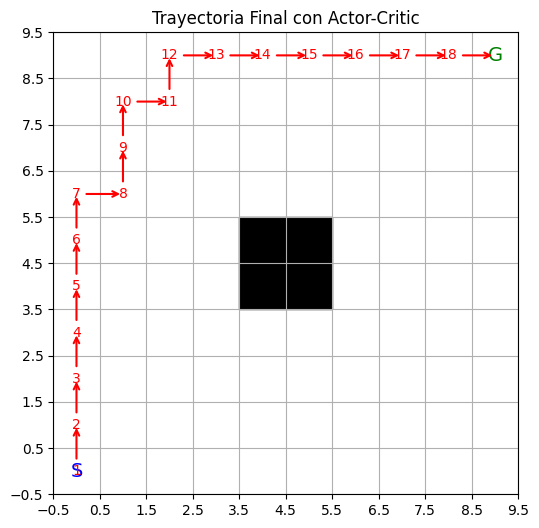

In [18]:
# --------------------------------------------------------
# Evaluación de la política final
# --------------------------------------------------------
# Usa la política entrenada (theta) para:
    # Ejecutar el agente de forma greedy
    # Generar una trayectoria
    # Ver si llega a la meta
    # Visualizar el camino

state = env.reset()
done = False
trajectory = [state]
for _ in range(MAX_STEPS):
    x,y = state
    probs = softmax(theta[x,y,:], tau=TAU_EVAL)  # casi determinista
    action = np.argmax(probs)
    state, reward, done, _ = env.step(action)
    trajectory.append(state)
    if done:
        break

print(f"Evaluación final: pasos={len(trajectory)}, llegó_meta={done}")

# Mostrar trayectoria con flechas numeradas
env.render_trajectory(trajectory)

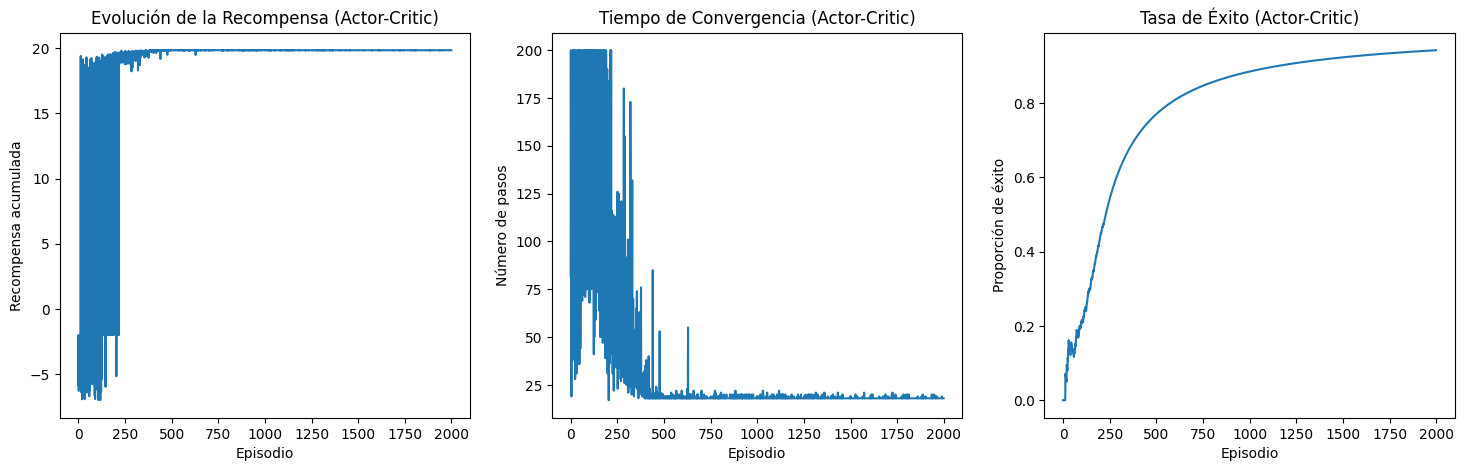

In [19]:
# --------------------------------------------------------
# Graficar métricas
# --------------------------------------------------------
fig, axs = plt.subplots(1,3, figsize=(18,5))

axs[0].plot(rewards)
axs[0].set_title("Evolución de la Recompensa (Actor-Critic)")
axs[0].set_xlabel("Episodio")
axs[0].set_ylabel("Recompensa acumulada")

axs[1].plot(steps)
axs[1].set_title("Tiempo de Convergencia (Actor-Critic)")
axs[1].set_xlabel("Episodio")
axs[1].set_ylabel("Número de pasos")

axs[2].plot(np.cumsum(success)/np.arange(1,len(success)+1))
axs[2].set_title("Tasa de Éxito (Actor-Critic)")
axs[2].set_xlabel("Episodio")
axs[2].set_ylabel("Proporción de éxito")

plt.show()

# **JUEGOS** CON APRENDIZAJE POR REFUERZO
<div style="border: 2px solid #4CAF50; padding: 10px; border-radius: 8px; background-color: #e8f5e9; text-align: center;">
  <strong style="font-size: 32px;">JUEGOS CON APRENDIZAJE POR REFUERZO</strong>
</div>

## Aprendizaje por Refuerzo: **el Pong**

- Tomado del blog [Aprende Machine Learning]: https://www.aprendemachinelearning.com/aprendizaje-por-refuerzo/.

- Se crea el juego del pong con interface gráfica de Matplotlib

El Agente deberá aprender a jugar sólo mediante premios y castigos.

Se crean las clases:

* Agente: implementará el algoritmo de Q-Learning
* Environment: será el tablero de juego

Se crea una función para comenzar a jugar, donde se entrena iterando miles de partidas de pong.

Finalmente, se ejecuta 1 partida con el agente ya entrenado


In [41]:
import numpy as np
import matplotlib.pyplot as plt
from random import randint
from time import sleep
from IPython.display import clear_output
from math import ceil,floor

%matplotlib inline

### Clase Agente

In [42]:
class PongAgent:
    
    def __init__(self, game, policy=None, discount_factor = 0.1, learning_rate = 0.1, ratio_explotacion = 0.9):

        # Creamos la tabla de politicas
        if policy is not None:
            self._q_table = policy
        else:
            position = list(game.positions_space.shape)
            position.append(len(game.action_space))
            self._q_table = np.zeros(position)
        
        self.discount_factor = discount_factor
        self.learning_rate = learning_rate
        self.ratio_explotacion = ratio_explotacion

    def get_next_step(self, state, game):
        
        # Damos un paso aleatorio...
        next_step = np.random.choice(list(game.action_space))
        
        # o tomaremos el mejor paso...
        if np.random.uniform() <= self.ratio_explotacion:
            # tomar el maximo
            idx_action = np.random.choice(np.flatnonzero(
                    self._q_table[state[0],state[1],state[2]] == self._q_table[state[0],state[1],state[2]].max()
                ))
            next_step = list(game.action_space)[idx_action]

        return next_step

    # actualizamos las politicas con las recompensas obtenidas
    def update(self, game, old_state, action_taken, reward_action_taken, new_state, reached_end):
        idx_action_taken =list(game.action_space).index(action_taken)

        actual_q_value_options = self._q_table[old_state[0], old_state[1], old_state[2]]
        actual_q_value = actual_q_value_options[idx_action_taken]

        future_q_value_options = self._q_table[new_state[0], new_state[1], new_state[2]]
        future_max_q_value = reward_action_taken  +  self.discount_factor*future_q_value_options.max()
        if reached_end:
            future_max_q_value = reward_action_taken #maximum reward

        self._q_table[old_state[0], old_state[1], old_state[2], idx_action_taken] = actual_q_value + \
                                              self.learning_rate*(future_max_q_value -actual_q_value)
    
    def print_policy(self):
        for row in np.round(self._q_table,1):
            for column in row:
                print('[', end='')
                for value in column:
                    print(str(value).zfill(5), end=' ')
                print('] ', end='')
            print('')
            
    def get_policy(self):
        return self._q_table
 

### Clase Environment

In [43]:
class PongEnvironment:
    
    def __init__(self, max_life=3, height_px = 40, width_px = 50, movimiento_px = 3):
        
        self.action_space = ['Arriba','Abajo']
        
        self._step_penalization = 0
        
        self.state = [0,0,0]
        
        self.total_reward = 0
        
        self.dx = movimiento_px
        self.dy = movimiento_px
        
        filas = ceil(height_px/movimiento_px)
        columnas = ceil(width_px/movimiento_px)
        
        self.positions_space = np.array([[[0 for z in range(columnas)] 
                                                  for y in range(filas)] 
                                                     for x in range(filas)])

        self.lives = max_life
        self.max_life=max_life
        
        self.x = randint(int(width_px/2), width_px) 
        self.y = randint(0, height_px-10)
        
        self.player_alto = int(height_px/4)

        self.player1 = self.player_alto  # posic. inicial del player
        
        self.score = 0
        
        self.width_px = width_px
        self.height_px = height_px
        self.radio = 2.5

    def reset(self):
        self.total_reward = 0
        self.state = [0,0,0]
        self.lives = self.max_life
        self.score = 0
        self.x = randint(int(self.width_px/2), self.width_px) 
        self.y = randint(0, self.height_px-10)
        return self.state

    def step(self, action, animate=False):
        self._apply_action(action, animate)
        done = self.lives <=0 # final
        reward = self.score
        reward += self._step_penalization
        self.total_reward += reward
        return self.state, reward , done

    def _apply_action(self, action, animate=False):
        
        if action == "Arriba":
            self.player1 += abs(self.dy)
        elif action == "Abajo":
            self.player1 -= abs(self.dy)
            
        self.avanza_player()

        self.avanza_frame()

        if animate:
            clear_output(wait=True);
            fig = self.dibujar_frame()
            plt.show()

        self.state = (floor(self.player1/abs(self.dy))-2, floor(self.y/abs(self.dy))-2, floor(self.x/abs(self.dx))-2)
    
    def detectaColision(self, ball_y, player_y):
        if (player_y+self.player_alto >= (ball_y-self.radio)) and (player_y <= (ball_y+self.radio)):
            return True
        else:
            return False
    
    def avanza_player(self):
        if self.player1 + self.player_alto >= self.height_px:
            self.player1 = self.height_px - self.player_alto
        elif self.player1 <= -abs(self.dy):
            self.player1 = -abs(self.dy)

    def avanza_frame(self):
        self.x += self.dx
        self.y += self.dy
        if self.x <= 3 or self.x > self.width_px:
            self.dx = -self.dx
            if self.x <= 3:
                ret = self.detectaColision(self.y, self.player1)

                if ret:
                    self.score = 10
                else:
                    self.score = -10
                    self.lives -= 1
                    if self.lives>0:
                        self.x = randint(int(self.width_px/2), self.width_px)
                        self.y = randint(0, self.height_px-10)
                        self.dx = abs(self.dx)
                        self.dy = abs(self.dy)
        else:
            self.score = 0

        if self.y < 0 or self.y > self.height_px:
            self.dy = -self.dy

    def dibujar_frame(self):
        fig = plt.figure(figsize=(5, 4))
        a1 = plt.gca()
        circle = plt.Circle((self.x, self.y), self.radio, fc='slategray', ec="black")
        a1.set_ylim(-5, self.height_px+5)
        a1.set_xlim(-5, self.width_px+5)

        rectangle = plt.Rectangle((-5, self.player1), 5, self.player_alto, fc='gold', ec="none")
        a1.add_patch(circle);
        a1.add_patch(rectangle)
        #a1.set_yticklabels([]);a1.set_xticklabels([]);
        plt.text(4, self.height_px, "SCORE:"+str(self.total_reward)+"  LIFE:"+str(self.lives), fontsize=12)
        if self.lives <=0:
            plt.text(10, self.height_px-14, "GAME OVER", fontsize=16)
        elif self.total_reward >= 1000:
            plt.text(10, self.height_px-14, "YOU WIN!", fontsize=16)
        return fig


### Juego

In [44]:
def play(rounds=5000, max_life=3, discount_factor = 0.1, learning_rate = 0.1,
         ratio_explotacion=0.9,learner=None, game=None, animate=False):

    if game is None:
        # si usamos movimiento_px = 5 creamos una tabla de politicas de 8x10
        # si usamos movimiento_px = 3 la tabla sera de 14x17
        game = PongEnvironment(max_life=max_life, movimiento_px = 3)
        
    if learner is None:
        print("Begin new Train!")
        learner = PongAgent(game, discount_factor = discount_factor,learning_rate = learning_rate, ratio_explotacion= ratio_explotacion)

    max_points= -9999
    first_max_reached = 0
    total_rw=0
    steps=[]

    for played_games in range(0, rounds):
        state = game.reset()
        reward, done = None, None
        
        itera=0
        while (done != True) and (itera < 3000 and game.total_reward<=100):
            old_state = np.array(state)
            next_action = learner.get_next_step(state, game)
            state, reward, done = game.step(next_action, animate=animate)
            if rounds > 1:
                learner.update(game, old_state, next_action, reward, state, done)
            itera+=1
        
        steps.append(itera)
        
        total_rw+=game.total_reward
        if game.total_reward > max_points:
            max_points=game.total_reward
            first_max_reached = played_games
        
        if played_games %500==0 and played_games >1 and not animate:
            print("-- Partidas[", played_games, "] Avg.Puntos[", int(total_rw/played_games),"]  AVG Steps[", int(np.array(steps).mean()), "] Max Score[", max_points,"]")
                
    if played_games>1:
        print('Partidas[',played_games,'] Avg.Puntos[',int(total_rw/played_games),'] Max score[', max_points,'] en partida[',first_max_reached,']')
        
    #learner.print_policy()
    
    return learner, game


### Entrenamiento

In [45]:
learner, game = play(rounds=5000, discount_factor = 0.2, learning_rate = 0.1, ratio_explotacion=0.85)


Begin new Train!
-- Partidas[ 500 ] Avg.Puntos[ 18 ]  AVG Steps[ 230 ] Max Score[ 110 ]
-- Partidas[ 1000 ] Avg.Puntos[ 24 ]  AVG Steps[ 249 ] Max Score[ 110 ]
-- Partidas[ 1500 ] Avg.Puntos[ 26 ]  AVG Steps[ 255 ] Max Score[ 110 ]
-- Partidas[ 2000 ] Avg.Puntos[ 27 ]  AVG Steps[ 258 ] Max Score[ 110 ]
-- Partidas[ 2500 ] Avg.Puntos[ 28 ]  AVG Steps[ 258 ] Max Score[ 110 ]
-- Partidas[ 3000 ] Avg.Puntos[ 29 ]  AVG Steps[ 262 ] Max Score[ 110 ]
-- Partidas[ 3500 ] Avg.Puntos[ 30 ]  AVG Steps[ 264 ] Max Score[ 110 ]
-- Partidas[ 4000 ] Avg.Puntos[ 30 ]  AVG Steps[ 263 ] Max Score[ 110 ]
-- Partidas[ 4500 ] Avg.Puntos[ 31 ]  AVG Steps[ 266 ] Max Score[ 110 ]
Partidas[ 4999 ] Avg.Puntos[ 32 ] Max score[ 110 ] en partida[ 89 ]


### Agente en acción

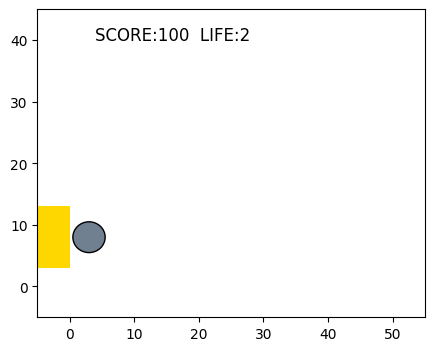

In [46]:
learner2 = PongAgent(game, policy=learner.get_policy())
learner2.ratio_explotacion = 1.0  # con esto quitamos las elecciones aleatorias al jugar
player = play(rounds=1, learner=learner2, game=game, animate=True)

## Juego **Triqui** con Q-Learning

In [47]:
import numpy as np
import random
import ipywidgets as widgets
from IPython.display import display, clear_output

# =========================================
# Definiciones
# =========================================
EMPTY = 0
X = 1   # Agente
O = -1  # Humano

# =========================================
# Entorno
# =========================================
def initial_state():
    return np.zeros((3,3), dtype=int)

def available_actions(state):
    return [(i,j) for i in range(3) for j in range(3) if state[i,j] == EMPTY]

def check_winner(state):
    for i in range(3):
        if abs(sum(state[i,:])) == 3:
            return np.sign(sum(state[i,:]))
        if abs(sum(state[:,i])) == 3:
            return np.sign(sum(state[:,i]))
    
    diag1 = state[0,0] + state[1,1] + state[2,2]
    diag2 = state[0,2] + state[1,1] + state[2,0]
    
    if abs(diag1) == 3:
        return np.sign(diag1)
    if abs(diag2) == 3:
        return np.sign(diag2)
    
    if not available_actions(state):
        return 0
    
    return None

def state_to_tuple(state):
    return tuple(state.flatten())

# =========================================
# Q-Learning
# =========================================
Q = {}
alpha = 0.1
gamma = 0.9
epsilon = 0.2

def get_Q(state, action):
    return Q.get((state, action), 0.0)

def choose_action(state):
    actions = available_actions(np.array(state).reshape(3,3))
    
    if random.random() < epsilon:
        return random.choice(actions)
    
    qs = [get_Q(state, a) for a in actions]
    max_q = max(qs)
    
    return actions[qs.index(max_q)]

def update_Q(state, action, reward, next_state):
    actions = available_actions(np.array(next_state).reshape(3,3))
    
    max_q_next = 0 if not actions else max(
        [get_Q(next_state, a) for a in actions]
    )
    
    old_q = get_Q(state, action)
    
    Q[(state, action)] = old_q + alpha * (reward + gamma * max_q_next - old_q)

# =========================================
# Entrenamiento
# =========================================
def train(episodes=10000):
    for _ in range(episodes):
        state = initial_state()
        current_player = X
        
        while True:
            s = state_to_tuple(state)
            action = choose_action(s)
            
            state[action] = current_player
            result = check_winner(state)
            s_next = state_to_tuple(state)
            
            if result is not None:
                reward = 1 if result == X else -1 if result == O else 0
                update_Q(s, action, reward, s_next)
                break
            else:
                update_Q(s, action, 0, s_next)
            
            current_player *= -1

# =========================================
# INTERFAZ 
# =========================================
state = initial_state()
buttons = []
status_label = widgets.Label(value="Tu turno")

def update_board():
    for i in range(3):
        for j in range(3):
            idx = i*3 + j
            if state[i,j] == X:
                buttons[idx].description = "X"
            elif state[i,j] == O:
                buttons[idx].description = "O"
            else:
                buttons[idx].description = ""

def disable_board():
    for b in buttons:
        b.disabled = True

def on_click(b):
    global state
    
    idx = buttons.index(b)
    i, j = idx // 3, idx % 3
    
    if state[i,j] != EMPTY:
        return
    
    # Jugada humano
    state[i,j] = O
    update_board()
    
    result = check_winner(state)
    if result is not None:
        end_game(result)
        return
    
    status_label.value = "Turno del agente..."
    
    # Jugada agente
    s = state_to_tuple(state)
    action = choose_action(s)
    state[action] = X
    
    update_board()
    
    result = check_winner(state)
    if result is not None:
        end_game(result)
        return
    
    status_label.value = "Tu turno"

def end_game(result):
    if result == X:
        status_label.value = "Gana el agente"
    elif result == O:
        status_label.value = "¡Ganaste!"
    else:
        status_label.value = "Empate"
    
    disable_board()

def play_gui():
    global buttons, state
    
    state = initial_state()
    buttons = []
    
    grid = widgets.GridBox(layout=widgets.Layout(grid_template_columns="repeat(3, 60px)"))
    
    for i in range(9):
        b = widgets.Button(description="", layout=widgets.Layout(width="60px", height="60px"))
        b.on_click(on_click)
        buttons.append(b)
    
    grid.children = buttons
    
    display(grid)
    display(status_label)

In [48]:
# =========================================
# Entrenar
# =========================================
train(10000)

In [49]:
# =========================================
# Jugar
# =========================================
play_gui()

GridBox(children=(Button(layout=Layout(height='60px', width='60px'), style=ButtonStyle()), Button(layout=Layou…

Label(value='Tu turno')

# AQUI